## Notebook setup

This section configures reproducibility (seeds), resolves workspace-relative paths, and defines small helper utilities used throughout the analysis.

In [3]:
from __future__ import annotations

import json
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

# Narrow suppression for a noisy NumPy FutureWarning emitted by Keras (tf2onnx export shim):
#   FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
# We filter by both message and module to make this robust across minor text changes.
warnings.filterwarnings(
    "ignore",
    message=r".*`np\.object`.*",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"keras\.src\.export\.tf2onnx_lib",
)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
 )

# Optional heavy deps: used only when we can compute train/valid proxy curves
try:
    import joblib
except Exception as e:  # pragma: no cover
    joblib = None

try:
    import scipy.sparse as sp
except Exception as e:  # pragma: no cover
    sp = None

try:
    import tensorflow as tf
except Exception as e:  # pragma: no cover
    tf = None

try:
    import keras_hub  # noqa: F401
except Exception as e:  # pragma: no cover
    keras_hub = None

try:
    from transformers import AutoTokenizer
except Exception as e:  # pragma: no cover
    AutoTokenizer = None

# ----------------------------
# Path resolution
# ----------------------------
NOTEBOOK_DIR = Path.cwd().resolve()


def find_project_root(start: Path) -> Path:
    """Find the repo root by walking upwards from a start path.

    Heuristic: identify the directory that contains 'requirements.txt'.

    Parameters
    ----------
    start:
        Starting directory (e.g., notebook working directory).

    Returns
    -------
    Path
        Resolved project root path.
    """
    cur = start
    while True:
        if (cur / 'requirements.txt').exists():
            return cur
        if cur.parent == cur:
            raise RuntimeError('Could not find project root (requirements.txt not found).')
        cur = cur.parent


PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)

# ----------------------------
# Config (seed + palette)
# ----------------------------
CONFIG_PATH = PROJECT_ROOT / 'config' / 'huffpost_category_text.json'
with CONFIG_PATH.open('r', encoding='utf-8') as f:
    CONFIG: Dict[str, Any] = json.load(f)

RANDOM_SEED = int(
    CONFIG.get('training', {}).get('random_seed')
    or CONFIG.get('split', {}).get('random_seed')
    or 42
 )

# ----------------------------
# Reproducibility
# ----------------------------
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if tf is not None:
    tf.random.set_seed(RANDOM_SEED)

# ----------------------------
# Plot styling (palette)
# ----------------------------
PALETTE = list(CONFIG.get('visualization', {}).get('color_palette') or [])
sns.set_theme(style='whitegrid')
if PALETTE:
    sns.set_palette(PALETTE)

# ----------------------------
# Analysis paths
# ----------------------------
CHARTS_DIR = NOTEBOOK_DIR / 'analysis_2025-12-23_09-15'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_ROOT = PROJECT_ROOT / 'data' / '04-predictions' / 'huffpost'
FEATURES_DIR = PROJECT_ROOT / 'data' / '03-features' / 'huffpost' / 'tfidf_v1'
PREPROCESSED_DIR = PROJECT_ROOT / 'data' / '02-preprocessed' / 'huffpost' / 'v1'

print('Notebook dir:', NOTEBOOK_DIR)
print('Project root:', PROJECT_ROOT)
print('Config path:', CONFIG_PATH)
print('Random seed:', RANDOM_SEED)
print('Charts dir:', CHARTS_DIR)
print('Predictions root:', PREDICTIONS_ROOT)

Notebook dir: D:\repos\ml_classification_example\notebooks
Project root: D:\repos\ml_classification_example
Config path: D:\repos\ml_classification_example\config\huffpost_category_text.json
Random seed: 42
Charts dir: D:\repos\ml_classification_example\notebooks\analysis_2025-12-23_09-15
Predictions root: D:\repos\ml_classification_example\data\04-predictions\huffpost


# A.1 — Dataset & Evaluation Strategy

This project uses a three-way split of the HuffPost dataset: **train**, **validation**, and **test**.

- The **validation split** is used during model development to tune training decisions (e.g., early stopping) and to compare model variants without looking at the test set.
- The **test set** is kept separate until the end to provide an unbiased estimate of generalization.
- For multi-class classification with a potentially imbalanced label distribution, appropriate metrics include **accuracy** and **macro-averaged F1** (macro-F1 is more sensitive to minority classes). We also inspect **per-class precision/recall/F1** and the **confusion matrix** to understand error patterns.

# A.2 — Training & Validation Analysis

The experiment folders in `data/04-predictions/` include saved models, predictions, and summary metrics. The pipelines in this repo do **not** currently persist per-epoch training history, so this notebook generates **proxy** training/validation plots from split-level evaluations.

For each experiment, we attempt to compute train/valid loss and accuracy by re-evaluating the saved model on the train/valid datasets. If a dependency is missing or the evaluation is too expensive, we fall back to plotting only the available split-level metrics from the saved artifacts.

In [4]:
@dataclass(frozen=True)
class ExperimentRun:
    """Container for experiment metadata and resolved run paths."""

    name: str
    run_dir: Path


def list_subdirs(path: Path) -> List[Path]:
    """List direct child directories (sorted by name)."""
    if not path.exists():
        return []
    return sorted([p for p in path.iterdir() if p.is_dir()], key=lambda p: p.name)


def find_latest_run_dir(experiment_dir: Path) -> Path:
    """Find the latest run directory under an experiment directory.

    The repo uses timestamp-named directories like '20251222T190244Z'.
    We select the lexicographically last directory name, which matches
    chronological ordering for this timestamp format.
    """
    subdirs = list_subdirs(experiment_dir)
    if not subdirs:
        raise FileNotFoundError(f'No run directories found under: {experiment_dir}')
    return subdirs[-1]


def read_json(path: Path) -> Dict[str, Any]:
    """Read a JSON file into a dict."""
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def load_metrics(run_dir: Path, split: str) -> Dict[str, Any]:
    """Load split-level metrics JSON from a run directory."""
    path = run_dir / f'metrics_{split}.json'
    if not path.exists():
        raise FileNotFoundError(f'Metrics not found: {path}')
    return read_json(path)


def load_predictions_df(run_dir: Path, split: str) -> pd.DataFrame:
    """Load predictions CSV for a split.

    Expected columns include: y_true, y_pred, y_true_label, y_pred_label.
    """
    path = run_dir / f'predictions_{split}.csv'
    if not path.exists():
        raise FileNotFoundError(f'Predictions not found: {path}')
    df = pd.read_csv(path)
    required = {'y_true', 'y_pred'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Missing columns {missing} in {path}')
    return df


def save_png(fig: plt.Figure, filename: str) -> Path:
    """Save a Matplotlib figure to the notebook charts folder."""
    out_path = CHARTS_DIR / filename
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    return out_path


# Resolve latest runs
experiments = []
for exp_name in ['tfidf_logreg', 'tfidf_dense', 'distilbert_frozen', 'distilbert_unfrozen']:
    exp_dir = PREDICTIONS_ROOT / exp_name
    run_dir = find_latest_run_dir(exp_dir)
    experiments.append(ExperimentRun(name=exp_name, run_dir=run_dir))

pd.DataFrame({'experiment': [e.name for e in experiments], 'latest_run_dir': [str(e.run_dir.relative_to(PROJECT_ROOT)) for e in experiments]})

,experiment,latest_run_dir
0,tfidf_logreg,data\04-predictions\huffpost\tfidf_logreg\2025...
1,tfidf_dense,data\04-predictions\huffpost\tfidf_dense\20251...
2,distilbert_frozen,data\04-predictions\huffpost\distilbert_frozen...
3,distilbert_unfrozen,data\04-predictions\huffpost\distilbert_unfroz...


## tfidf_logreg — Training vs validation curves (proxy)

This plot compares **train vs validation** performance for the TF-IDF + Logistic Regression model. Because the pipeline does not save per-epoch history, we compute split-level loss/accuracy by re-evaluating the saved model on the train and validation feature matrices.

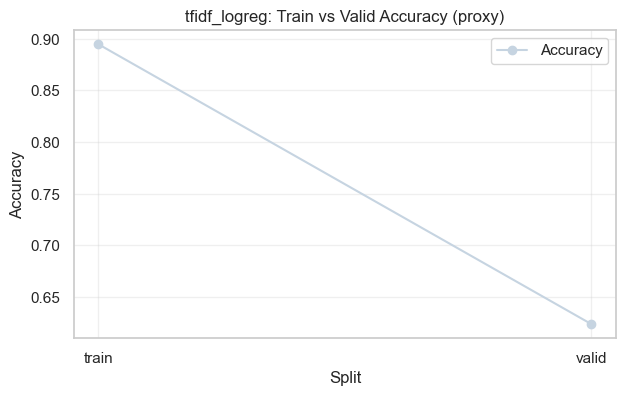

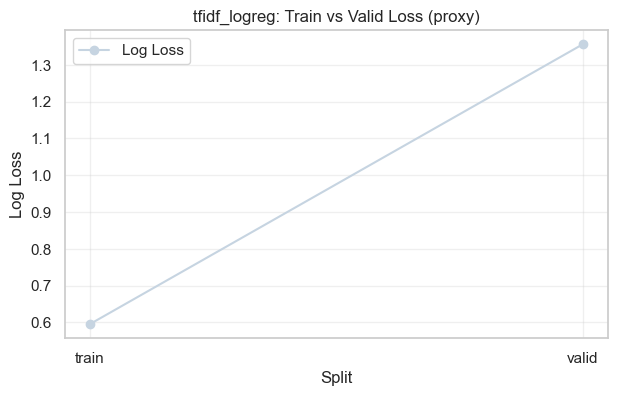

In [5]:
def eval_tfidf_logreg_split_metrics(run_dir: Path) -> pd.DataFrame:
    """Compute train/valid proxy metrics for TF-IDF Logistic Regression.

    Returns a dataframe with columns: split, loss, accuracy. Loss is
    computed as multi-class log loss.
    """
    if joblib is None or sp is None:
        raise RuntimeError('joblib/scipy are required to evaluate TF-IDF models.')

    model_path = run_dir / 'model.joblib'
    if not model_path.exists():
        raise FileNotFoundError(f'Missing model artifact: {model_path}')

    model = joblib.load(model_path)

    x_train = sp.load_npz(FEATURES_DIR / 'X_train.npz')
    x_valid = sp.load_npz(FEATURES_DIR / 'X_valid.npz')
    y_train = np.load(FEATURES_DIR / 'y_train.npy')
    y_valid = np.load(FEATURES_DIR / 'y_valid.npy')

    rows = []
    for split, x, y in (('train', x_train, y_train), ('valid', x_valid, y_valid)):
        proba = model.predict_proba(x)
        y_pred = np.asarray(np.argmax(proba, axis=1), dtype=np.int64)
        rows.append(
            {
                'split': split,
                'loss': float(log_loss(y, proba)),
                'accuracy': float(accuracy_score(y, y_pred)),
            }
        )
    return pd.DataFrame(rows)


run_dir = next(e.run_dir for e in experiments if e.name == 'tfidf_logreg')
try:
    df_curve = eval_tfidf_logreg_split_metrics(run_dir)
except Exception as e:
    print('Could not compute train/valid proxy metrics:', e)
    # Fallback: plot only saved validation metrics as a single point
    valid = load_metrics(run_dir, 'valid')['metrics']
    df_curve = pd.DataFrame([{'split': 'valid', 'loss': np.nan, 'accuracy': float(valid.get('accuracy', np.nan))}])

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(df_curve['split'], df_curve['accuracy'], marker='o', label='Accuracy')
ax1.set_title('tfidf_logreg: Train vs Valid Accuracy (proxy)')
ax1.set_xlabel('Split')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')
save_png(fig, 'tfidf_logreg_train_vs_valid_accuracy.png')
plt.show()

fig, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(df_curve['split'], df_curve['loss'], marker='o', label='Log Loss')
ax2.set_title('tfidf_logreg: Train vs Valid Loss (proxy)')
ax2.set_xlabel('Split')
ax2.set_ylabel('Log Loss')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')
save_png(fig, 'tfidf_logreg_train_vs_valid_loss.png')
plt.show()

## tfidf_dense — Training vs validation curves (proxy)

This plot compares **train vs validation** performance for the TF-IDF + TruncatedSVD + small dense network model. We compute split-level metrics by loading the saved SVD transformer and Keras model and evaluating on the stored feature matrices.

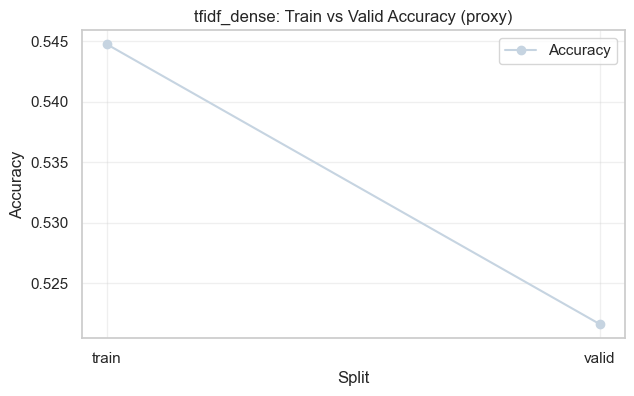

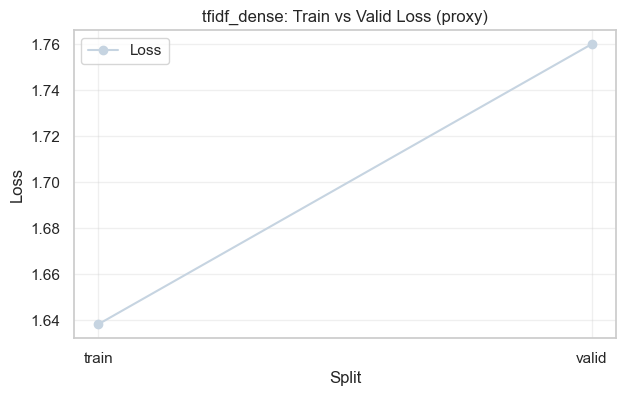

In [6]:
def eval_tfidf_dense_split_metrics(run_dir: Path) -> pd.DataFrame:
    """Compute train/valid proxy metrics for TF-IDF Dense model.

    Returns a dataframe with columns: split, loss, accuracy.
    """
    if joblib is None or sp is None or tf is None:
        raise RuntimeError('joblib/scipy/tensorflow are required to evaluate the dense model.')

    svd_path = run_dir / 'svd.joblib'
    model_path = run_dir / 'keras_model.keras'
    if not svd_path.exists():
        raise FileNotFoundError(f'Missing SVD artifact: {svd_path}')
    if not model_path.exists():
        raise FileNotFoundError(f'Missing Keras model artifact: {model_path}')

    svd = joblib.load(svd_path)
    model = tf.keras.models.load_model(model_path)

    x_train = sp.load_npz(FEATURES_DIR / 'X_train.npz')
    x_valid = sp.load_npz(FEATURES_DIR / 'X_valid.npz')
    y_train = np.load(FEATURES_DIR / 'y_train.npy')
    y_valid = np.load(FEATURES_DIR / 'y_valid.npy')

    x_train_dense = svd.transform(x_train)
    x_valid_dense = svd.transform(x_valid)

    rows = []
    for split, x, y in (('train', x_train_dense, y_train), ('valid', x_valid_dense, y_valid)):
        # Keras evaluate returns [loss, accuracy] because we compiled with an accuracy metric.
        loss_val, acc_val = model.evaluate(x, y, verbose=0)
        rows.append({'split': split, 'loss': float(loss_val), 'accuracy': float(acc_val)})
    return pd.DataFrame(rows)


run_dir = next(e.run_dir for e in experiments if e.name == 'tfidf_dense')
try:
    df_curve = eval_tfidf_dense_split_metrics(run_dir)
except Exception as e:
    print('Could not compute train/valid proxy metrics:', e)
    valid = load_metrics(run_dir, 'valid')['metrics']
    df_curve = pd.DataFrame([{'split': 'valid', 'loss': np.nan, 'accuracy': float(valid.get('accuracy', np.nan))}])

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(df_curve['split'], df_curve['accuracy'], marker='o', label='Accuracy')
ax1.set_title('tfidf_dense: Train vs Valid Accuracy (proxy)')
ax1.set_xlabel('Split')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')
save_png(fig, 'tfidf_dense_train_vs_valid_accuracy.png')
plt.show()

fig, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(df_curve['split'], df_curve['loss'], marker='o', label='Loss')
ax2.set_title('tfidf_dense: Train vs Valid Loss (proxy)')
ax2.set_xlabel('Split')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')
save_png(fig, 'tfidf_dense_train_vs_valid_loss.png')
plt.show()

## distilbert_frozen — Training vs validation curves (proxy)

This plot compares **train vs validation** performance for the frozen DistilBERT model. We attempt to re-evaluate the saved model on train/validation text using the saved tokenizer and label encoder.

Because this can be slow on CPU, the evaluation uses an optional row cap for the training split (configurable in the code cell).

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


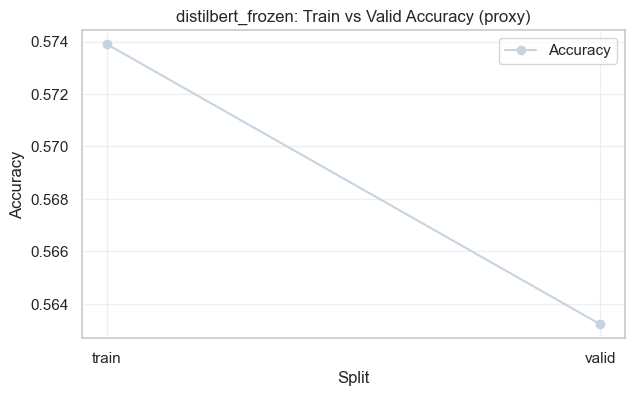

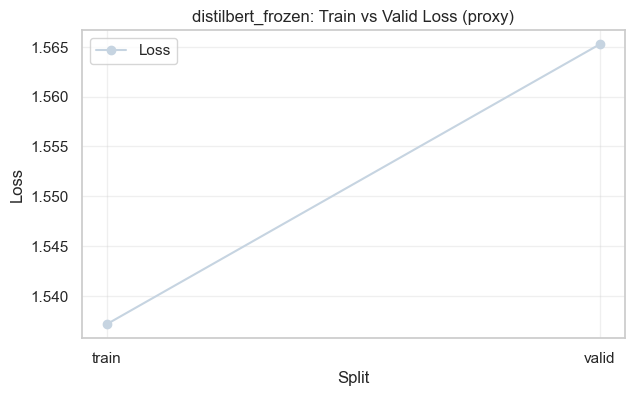

In [7]:
BERT_TRAIN_MAX_ROWS: Optional[int] = 20000
BERT_VALID_MAX_ROWS: Optional[int] = None


def eval_distilbert_split_metrics(run_dir: Path, *, max_length: int) -> pd.DataFrame:
    """Compute train/valid proxy metrics for DistilBERT models.

    Notes
    -----
    - Uses the saved tokenizer folder under the run dir.
    - Uses the shared label encoder in the TF-IDF feature folder (same label space).
    - Computes cross-entropy loss from logits and accuracy.
    """
    if tf is None or AutoTokenizer is None or joblib is None:
        raise RuntimeError('tensorflow, transformers, and joblib are required to evaluate DistilBERT models.')

    model_path = run_dir / 'keras_model.keras'
    tok_dir = run_dir / 'tokenizer'
    if not model_path.exists():
        raise FileNotFoundError(f'Missing Keras model artifact: {model_path}')
    if not tok_dir.exists():
        raise FileNotFoundError(f'Missing tokenizer folder: {tok_dir}')

    label_encoder = joblib.load(FEATURES_DIR / 'label_encoder.joblib')
    model = tf.keras.models.load_model(model_path)
    tokenizer = AutoTokenizer.from_pretrained(str(tok_dir))

    def load_split_df(split: str, *, max_rows: Optional[int]) -> pd.DataFrame:
        path = PREPROCESSED_DIR / f'{split}.csv'
        df = pd.read_csv(path)
        if max_rows is not None:
            df = df.head(int(max_rows)).copy()
        return df

    def encode(text: Iterable[str]) -> Dict[str, tf.Tensor]:
        enc = tokenizer(
            list(text),
            truncation=True,
            padding='max_length',
            max_length=int(max_length),
            return_tensors='tf',
        )
        token_ids = tf.cast(enc['input_ids'], tf.int32)
        padding_mask = tf.cast(enc['attention_mask'], tf.int32)
        return {'token_ids': token_ids, 'padding_mask': padding_mask}

    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    rows = []
    for split, max_rows in (('train', BERT_TRAIN_MAX_ROWS), ('valid', BERT_VALID_MAX_ROWS)):
        df = load_split_df(split, max_rows=max_rows)
        if 'text' not in df.columns or 'category' not in df.columns:
            raise ValueError(f'Expected columns not found in {split}.csv')

        x = encode(df['text'].astype(str).tolist())
        y = label_encoder.transform(df['category'].astype(str).tolist()).astype(np.int64)

        logits = model.predict(x, batch_size=32, verbose=0)
        y_pred = np.asarray(np.argmax(np.asarray(logits), axis=1), dtype=np.int64)

        # Compute mean loss
        loss_val = float(loss_fn(y, logits).numpy())
        acc_val = float(accuracy_score(y, y_pred))

        rows.append({'split': split, 'loss': loss_val, 'accuracy': acc_val})

    return pd.DataFrame(rows)


run_dir = next(e.run_dir for e in experiments if e.name == 'distilbert_frozen')
valid_meta = load_metrics(run_dir, 'valid')
max_length = int(valid_meta.get('extra', {}).get('max_length', 64))

try:
    df_curve = eval_distilbert_split_metrics(run_dir, max_length=max_length)
except Exception as e:
    print('Could not compute train/valid proxy metrics:', e)
    valid = valid_meta['metrics']
    df_curve = pd.DataFrame([{'split': 'valid', 'loss': np.nan, 'accuracy': float(valid.get('accuracy', np.nan))}])

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(df_curve['split'], df_curve['accuracy'], marker='o', label='Accuracy')
ax1.set_title('distilbert_frozen: Train vs Valid Accuracy (proxy)')
ax1.set_xlabel('Split')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')
save_png(fig, 'distilbert_frozen_train_vs_valid_accuracy.png')
plt.show()

fig, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(df_curve['split'], df_curve['loss'], marker='o', label='Loss')
ax2.set_title('distilbert_frozen: Train vs Valid Loss (proxy)')
ax2.set_xlabel('Split')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')
save_png(fig, 'distilbert_frozen_train_vs_valid_loss.png')
plt.show()

## distilbert_unfrozen — Training vs validation curves (proxy)

This plot compares **train vs validation** performance for the unfrozen (fine-tuned) DistilBERT model using the same proxy evaluation approach as the frozen variant.

In [ ]:
run_dir = next(e.run_dir for e in experiments if e.name == 'distilbert_unfrozen')
valid_meta = load_metrics(run_dir, 'valid')
max_length = int(valid_meta.get('extra', {}).get('max_length', 64))

try:
    df_curve = eval_distilbert_split_metrics(run_dir, max_length=max_length)
except Exception as e:
    print('Could not compute train/valid proxy metrics:', e)
    valid = valid_meta['metrics']
    df_curve = pd.DataFrame([{'split': 'valid', 'loss': np.nan, 'accuracy': float(valid.get('accuracy', np.nan))}])

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(df_curve['split'], df_curve['accuracy'], marker='o', label='Accuracy')
ax1.set_title('distilbert_unfrozen: Train vs Valid Accuracy (proxy)')
ax1.set_xlabel('Split')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')
save_png(fig, 'distilbert_unfrozen_train_vs_valid_accuracy.png')
plt.show()

fig, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(df_curve['split'], df_curve['loss'], marker='o', label='Loss')
ax2.set_title('distilbert_unfrozen: Train vs Valid Loss (proxy)')
ax2.set_xlabel('Split')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')
save_png(fig, 'distilbert_unfrozen_train_vs_valid_loss.png')
plt.show()

# A.3 — Test Set Evaluation

This section evaluates each experiment on the **held-out test set** using the saved `predictions_test.csv` artifacts. For each model, we compute and visualize a confusion matrix, produce per-class metrics, and summarize overall accuracy and F1 (macro/micro/weighted).

In [ ]:
def compute_test_metrics_from_predictions(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, float], List[str]]:
    """Compute per-class and overall metrics from a predictions dataframe.

    Parameters
    ----------
    df:
        Predictions dataframe containing y_true, y_pred and optionally label columns.

    Returns
    -------
    per_class_df:
        Per-class precision/recall/F1/support table.
    f1_df:
        Macro/micro/weighted F1 summary table.
    overall:
        Overall metrics dict with accuracy and aggregate F1 scores.
    labels:
        Ordered class label strings (used for confusion matrix axes).
    """
    if 'y_true_label' in df.columns and 'y_pred_label' in df.columns:
        y_true = df['y_true_label'].astype(str).to_numpy()
        y_pred = df['y_pred_label'].astype(str).to_numpy()
        labels = sorted(pd.unique(np.concatenate([y_true, y_pred])).tolist())
    else:
        y_true = df['y_true'].to_numpy()
        y_pred = df['y_pred'].to_numpy()
        labels = sorted(pd.unique(np.concatenate([y_true, y_pred])).tolist())

    report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    per_class_rows = []
    for label in labels:
        row = report.get(label, {})
        per_class_rows.append(
            {
                'class': label,
                'precision': float(row.get('precision', np.nan)),
                'recall': float(row.get('recall', np.nan)),
                'f1': float(row.get('f1-score', np.nan)),
                'support': int(row.get('support', 0)),
            }
        )

    per_class_df = pd.DataFrame(per_class_rows).sort_values('support', ascending=False)

    overall = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro')),
        'f1_micro': float(f1_score(y_true, y_pred, average='micro')),
        'f1_weighted': float(f1_score(y_true, y_pred, average='weighted')),
    }
    f1_df = pd.DataFrame(
        [
            {'average': 'macro', 'f1': overall['f1_macro']},
            {'average': 'micro', 'f1': overall['f1_micro']},
            {'average': 'weighted', 'f1': overall['f1_weighted']},
        ]
    )

    return per_class_df, f1_df, overall, labels


def plot_confusion_matrix(df: pd.DataFrame, labels: List[str], *, title: str, filename: str) -> None:
    """Plot and save a confusion matrix for labeled predictions."""
    if 'y_true_label' in df.columns and 'y_pred_label' in df.columns:
        y_true = df['y_true_label'].astype(str).to_numpy()
        y_pred = df['y_pred_label'].astype(str).to_numpy()
    else:
        y_true = df['y_true'].to_numpy()
        y_pred = df['y_pred'].to_numpy()

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues', ax=ax, cbar=True)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    # Tick labels can be large; show every Nth label
    step = max(1, len(labels) // 25)
    ax.set_xticks(np.arange(0.5, len(labels) + 0.5, step))
    ax.set_yticks(np.arange(0.5, len(labels) + 0.5, step))
    ax.set_xticklabels([labels[i] for i in range(0, len(labels), step)], rotation=90)
    ax.set_yticklabels([labels[i] for i in range(0, len(labels), step)], rotation=0)

    save_png(fig, filename)
    plt.show()

## tfidf_logreg — Test evaluation

We evaluate the Logistic Regression model on the held-out test set using the saved predictions. The confusion matrix highlights which categories are commonly confused, while per-class precision/recall/F1 show which labels are hardest to predict.

In [ ]:
run_dir = next(e.run_dir for e in experiments if e.name == 'tfidf_logreg')
df_test = load_predictions_df(run_dir, 'test')
per_class_df, f1_df, overall, labels = compute_test_metrics_from_predictions(df_test)

print('Final test metrics (computed from predictions):')
print(json.dumps(overall, indent=2))

plot_confusion_matrix(
    df_test,
    labels,
    title='tfidf_logreg: Confusion Matrix (Test)',
    filename='tfidf_logreg_confusion_matrix_test.png',
)

display(per_class_df.head(20))
display(f1_df)

## tfidf_dense — Test evaluation

We evaluate the TF-IDF + Dense model on the test set using the saved predictions. Comparing its confusion patterns to TF-IDF Logistic Regression helps diagnose whether additional modeling capacity improves minority classes or mostly benefits frequent labels.

In [ ]:
run_dir = next(e.run_dir for e in experiments if e.name == 'tfidf_dense')
df_test = load_predictions_df(run_dir, 'test')
per_class_df, f1_df, overall, labels = compute_test_metrics_from_predictions(df_test)

print('Final test metrics (computed from predictions):')
print(json.dumps(overall, indent=2))

plot_confusion_matrix(
    df_test,
    labels,
    title='tfidf_dense: Confusion Matrix (Test)',
    filename='tfidf_dense_confusion_matrix_test.png',
)

display(per_class_df.head(20))
display(f1_df)

## distilbert_frozen — Test evaluation

We evaluate the frozen DistilBERT model on the test set using the saved predictions. Transformer-based models may better capture semantic structure in text, which can improve performance on ambiguous or longer categories—but may still confuse closely-related labels.

In [ ]:
run_dir = next(e.run_dir for e in experiments if e.name == 'distilbert_frozen')
df_test = load_predictions_df(run_dir, 'test')
per_class_df, f1_df, overall, labels = compute_test_metrics_from_predictions(df_test)

print('Final test metrics (computed from predictions):')
print(json.dumps(overall, indent=2))

plot_confusion_matrix(
    df_test,
    labels,
    title='distilbert_frozen: Confusion Matrix (Test)',
    filename='distilbert_frozen_confusion_matrix_test.png',
)

display(per_class_df.head(20))
display(f1_df)

## distilbert_unfrozen — Test evaluation

We evaluate the fine-tuned DistilBERT model on the test set using the saved predictions. Fine-tuning typically improves task-specific performance but can overfit; the confusion matrix and per-class metrics help detect whether gains are broad-based or limited to common classes.

In [ ]:
run_dir = next(e.run_dir for e in experiments if e.name == 'distilbert_unfrozen')
df_test = load_predictions_df(run_dir, 'test')
per_class_df, f1_df, overall, labels = compute_test_metrics_from_predictions(df_test)

print('Final test metrics (computed from predictions):')
print(json.dumps(overall, indent=2))

plot_confusion_matrix(
    df_test,
    labels,
    title='distilbert_unfrozen: Confusion Matrix (Test)',
    filename='distilbert_unfrozen_confusion_matrix_test.png',
)

display(per_class_df.head(20))
display(f1_df)